In [23]:
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
sys.path.append("../")
from src.features.skill_extraction import extract_skill_features

# Thiết lập môi trường

Notebook này thực hiện preprocessing và feature engineering cho dữ liệu tin tuyển dụng LinkedIn.

Các bước chính gồm đọc dữ liệu, xử lý outlier, trích xuất kỹ năng, tạo đặc trưng thời gian, xử lý lương và trực quan hóa kết quả.

In [3]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 1. Đọc dữ liệu

Sử dụng `postings.csv` vì file này chứa các trường văn bản `title`, `description` và `skills_desc` cần cho việc trích xuất kỹ năng.

In [14]:
DATA_PATH = r'D:\AI_LAB\DS_Job_Recommend_Projects\data\raw\postings.csv'
data = pd.read_csv(DATA_PATH)
print(f"Kích thước tập dữ liệu: {data.shape[0]} dòng, {data.shape[1]} cột")
data.info()

Kích thước tập dữ liệu: 123849 dòng, 31 cột
<class 'pandas.DataFrame'>
RangeIndex: 123849 entries, 0 to 123848
Data columns (total 31 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   job_id                      123849 non-null  int64  
 1   company_name                122130 non-null  str    
 2   title                       123849 non-null  str    
 3   description                 123842 non-null  str    
 4   max_salary                  29793 non-null   float64
 5   pay_period                  36073 non-null   str    
 6   location                    123849 non-null  str    
 7   company_id                  122132 non-null  float64
 8   views                       122160 non-null  float64
 9   med_salary                  6280 non-null    float64
 10  min_salary                  29793 non-null   float64
 11  formatted_work_type         123849 non-null  str    
 12  applies                     23320 non-n

## 2. Xử lý outlier

Thử nghiệm IQR capping trên `views` để giới hạn các giá trị cực đoan mà không loại bỏ toàn bộ dòng dữ liệu.

In [9]:
def cap_outliers_iqr(series, factor=1.5):
    """Cắt ngọn outliers dựa trên dải IQR (Buổi 6)"""
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - factor * iqr
    upper_bound = q3 + factor * iqr
    
    # Sử dụng np.clip vector hóa của NumPy để ép dải trị số cực nhanh (Buổi 2)
    return np.clip(series, lower_bound, upper_bound)

# Chạy thử nghiệm trên cột 'views'
if 'views' in data.columns:
    data['views_capped'] = cap_outliers_iqr(data['views'])
    
    # Vẽ biểu đồ so sánh trước và sau khi xử lý (Buổi 8-9)
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    sns.histplot(data['views'], kde=True, ax=axes[0]).set(title='Trước khi xử lý Outliers')
    sns.histplot(data['views_capped'], kde=True, ax=axes[1]).set(title='Sau khi xử lý Outliers (Capped)')
    plt.show()


## 3. Trích xuất đặc trưng kỹ năng

Gộp nội dung từ `title`, `description` và `skills_desc`, sau đó tạo các cột nhị phân `has_*` và tổng số kỹ năng `skill_count`.

In [ ]:
text_columns = [column for column in ["title", "description", "skills_desc"] if column in data.columns]
df_features = extract_skill_features(data, text_columns)

skill_cols = [column for column in df_features.columns if column.startswith("has_")]
print(f"Successfully extracted {len(skill_cols)} new skill features")
df_features[skill_cols + ["skill_count"]].head()

Đã trích xuất thành công 23 đặc trưng kỹ năng mới!


,has_python,has_sql,has_java,has_javascript,has_typescript,has_r,has_c++,has_c#,has_aws,has_azure,...,has_pandas,has_numpy,has_machine_learning,has_deep_learning,has_tensorflow,has_pytorch,has_scikit_learn,has_leadership,has_management,skill_count
0,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,2
1,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,3
2,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,3
3,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
4,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


## 4. Tạo đặc trưng thời gian

Chuyển timestamp sang datetime và tạo các đặc trưng về thời lượng đăng tin, tháng, ngày trong tuần, giờ đăng và cuối tuần.

In [17]:
# 1. Chuyển đổi các cột timestamp (mili-giây) sang định dạng Datetime chuẩn (Buổi 7)
datetime_cols = ['listed_time', 'expiry']

for col in datetime_cols:
    if col in df_features.columns:
        # Sử dụng unit='ms' vì dữ liệu LinkedIn thường lưu timestamp ở dạng mili-giây
        df_features[col] = pd.to_datetime(df_features[col], unit='ms', errors='coerce')

print("Đã chuẩn hóa thành công các cột thời gian!")

# 2. Trích xuất các đặc trưng mới từ thuộc tính .dt (Buổi 7)
# Tính thời gian hiển thị của tin tuyển dụng trước khi hết hạn (đơn vị: Ngày)
if 'listed_time' in df_features.columns and 'expiry' in df_features.columns:
    df_features['duration_days'] = (df_features['expiry'] - df_features['listed_time']).dt.total_seconds() / (24 * 3600)

# Trích xuất tháng, thứ trong tuần, và giờ đăng tin tuyển dụng
if 'listed_time' in df_features.columns:
    df_features['post_month'] = df_features['listed_time'].dt.month
    df_features['post_dayofweek'] = df_features['listed_time'].dt.dayofweek  # 0: Thứ 2, 6: Chủ nhật
    df_features['post_hour'] = df_features['listed_time'].dt.hour
    
    # Tạo đặc trưng nhị phân: Tin tuyển dụng có đăng vào cuối tuần hay không?
    df_features['is_weekend'] = df_features['post_dayofweek'].apply(lambda x: 1 if x >= 5 else 0)

# Xem thử kết quả các cột thời gian mới tạo ra
time_features = ['listed_time', 'expiry', 'duration_days', 'post_dayofweek', 'is_weekend']
df_features[[col for col in time_features if col in df_features.columns]].head()

Đã chuẩn hóa thành công các cột thời gian!


,listed_time,expiry,duration_days,post_dayofweek,is_weekend
0,2024-04-17 23:45:08,2024-05-17 23:45:08,30.0,2,0
1,2024-04-11 17:51:27,2024-05-11 17:51:27,30.0,3,0
2,2024-04-16 14:26:54,2024-05-16 14:26:54,30.0,1,0
3,2024-04-12 04:23:32,2024-05-12 04:23:32,30.0,4,0
4,2024-04-18 14:52:23,2024-05-18 14:52:23,30.0,3,0


## 5. Xử lý đặc trưng lương

Điền missing salary theo trung vị của `title`, dùng trung vị toàn cục làm phương án dự phòng, sau đó áp dụng log transformation để giảm độ lệch phân phối.

In [18]:
# 1. Kiểm tra tỷ lệ khuyết thiếu của cột lương trước khi xử lý
missing_before = df_features['min_salary'].isnull().mean() * 100
print(f"Tỷ lệ khuyết thiếu của 'min_salary' TRƯỚC xử lý: {missing_before:.2f}%")

# 2. Điền khuyết thông minh bằng Trung vị theo nhóm Tiêu đề công việc (Groupby Imputation - Buổi 6)
# Chúng ta dùng .transform('median') để tính trung vị nhóm và gán ngược lại dòng tương ứng
if 'min_salary' in df_features.columns and 'title' in df_features.columns:
    df_features['min_salary_imputed'] = df_features['min_salary'].fillna(
        df_features.groupby('title')['min_salary'].transform('median')
    )
    
    # Đối với những title quá hiếm (không tính được trung vị nhóm), ta điền bằng trung vị toàn cục
    global_median_min = df_features['min_salary'].median()
    df_features['min_salary_imputed'] = df_features['min_salary_imputed'].fillna(global_median_min)

if 'max_salary' in df_features.columns and 'title' in df_features.columns:
    df_features['max_salary_imputed'] = df_features['max_salary'].fillna(
        df_features.groupby('title')['max_salary'].transform('median')
    )
    global_median_max = df_features['max_salary'].median()
    df_features['max_salary_imputed'] = df_features['max_salary_imputed'].fillna(global_median_max)

# 3. Biến đổi Logarit (Log Transformation - Buổi 2) để đưa phân phối lương về dạng chuẩn
df_features['log_min_salary'] = np.log1p(df_features['min_salary_imputed'])
df_features['log_max_salary'] = np.log1p(df_features['max_salary_imputed'])

# 4. Kiểm tra lại kết quả sau khi điền khuyết
missing_after = df_features['min_salary_imputed'].isnull().mean() * 100
print(f"Tỷ lệ khuyết thiếu của 'min_salary' SAU xử lý: {missing_after:.2f}%")

# Hiển thị bảng so sánh đối chiếu 10 dòng đầu
df_features[['title', 'min_salary', 'min_salary_imputed', 'log_min_salary']].head(10)

Tỷ lệ khuyết thiếu của 'min_salary' TRƯỚC xử lý: 75.94%
Tỷ lệ khuyết thiếu của 'min_salary' SAU xử lý: 0.00%


,title,min_salary,min_salary_imputed,log_min_salary
0,Marketing Coordinator,17.0,17.00,2.890372
1,Mental Health Therapist/Counselor,30.0,30.00,3.433987
2,Assitant Restaurant Manager,45000.0,45000.00,10.714440
3,Senior Elder Law / Trusts and Estates Associat...,140000.0,140000.00,11.849405
4,Service Technician,60000.0,60000.00,11.002117
5,Economic Development and Planning Intern,14.0,14.00,2.708050
6,Producer,60000.0,60000.00,11.002117
7,Building Engineer,90000.0,90000.00,11.407576
8,Respiratory Therapist,NaN,35.77,3.604682
9,Worship Leader,NaN,60000.00,11.002117


## 6. Trực quan hóa và kiểm tra kết quả

So sánh phân phối `skill_count` theo cấp bậc và tỷ lệ các kỹ năng chính theo từng nhóm kinh nghiệm.

C:\Users\SU\AppData\Local\Temp\ipykernel_16848\467501175.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


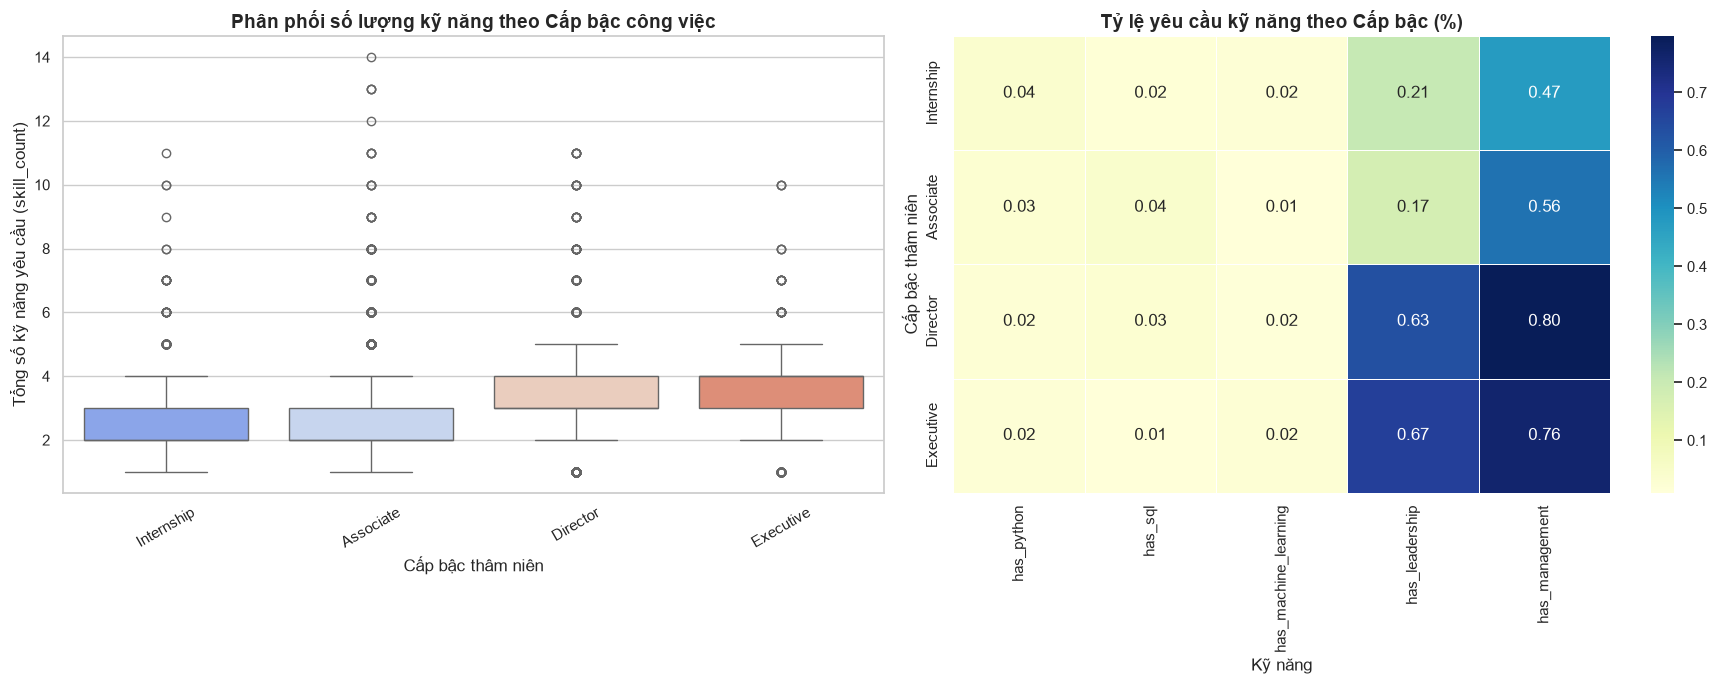

In [22]:
# Đảm bảo các đồ thị hiển thị đẹp mắt theo chuẩn Buổi 9
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# -------------------------------------------------------------
# BIỂU ĐỒ 1: Phân phối tổng số kỹ năng theo từng cấp bậc (Boxplot)
# -------------------------------------------------------------
# Thiết lập thứ tự hiển thị từ thấp đến cao để dễ quan sát xu hướng
level_order = ['Internship', 'Entry Level', 'Associate', 'Mid-Senior Level', 'Director', 'Executive']
actual_order = [lvl for lvl in level_order if lvl in df_features['formatted_experience_level'].unique()]

sns.boxplot(
    data=df_features,
    x='formatted_experience_level',
    y='skill_count',
    order=actual_order,
    palette='coolwarm',
    ax=axes[0]
)
axes[0].set_title('Phân phối số lượng kỹ năng theo Cấp bậc công việc', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Cấp bậc thâm niên', fontsize=12)
axes[0].set_ylabel('Tổng số kỹ năng yêu cầu (skill_count)', fontsize=12)
axes[0].tick_params(axis='x', rotation=30)

# -------------------------------------------------------------
# BIỂU ĐỒ 2: Tỷ lệ yêu cầu các kỹ năng chính theo cấp bậc (Heatmap - Buổi 6 & 9)
# -------------------------------------------------------------
# Chọn ra một số kỹ năng tiêu biểu để so sánh
target_skills = ['has_python', 'has_sql', 'has_machine_learning', 'has_leadership', 'has_management']
existing_skills = [col for col in target_skills if col in df_features.columns]

if existing_skills:
    # Sử dụng GroupBy (Buổi 6) để tính tỷ lệ trung bình xuất hiện kỹ năng của mỗi cấp bậc
    skill_by_level = df_features.groupby('formatted_experience_level')[existing_skills].mean()
    # Sắp xếp lại các dòng theo thứ tự thâm niên tăng dần
    skill_by_level = skill_by_level.reindex(actual_order)

    sns.heatmap(
        skill_by_level,
        annot=True,
        cmap='YlGnBu',
        fmt='.2f',
        linewidths=0.5,
        ax=axes[1]
    )
    axes[1].set_title('Tỷ lệ yêu cầu kỹ năng theo Cấp bậc (%)', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Kỹ năng', fontsize=12)
    axes[1].set_ylabel('Cấp bậc thâm niên', fontsize=12)

plt.tight_layout()
plt.show()